Importing Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

##For Malayalam

####Data- loading, tokenization, etc

In [3]:
train_data = pd.read_csv('/content/ai-gen product review detect - mal_train.csv')
test_data = pd.read_csv('//content/ai-gen product review detect - mal_test.csv')

print("Training Data:")
print(train_data.head())
print("\nTest Data:")
print(test_data.head())

Training Data:
                ID                                               DATA  LABEL
0  MAL_HUAI_TR_001  ഞാൻ കുറച്ച് കാലമായി മുച്ചട്ച്ചിൻ്റെ ഫേസ് വാഷ് ...  HUMAN
1  MAL_HUAI_TR_002           ഈ ഫേസ് വാഷ് തണുപ്പ് വെതറിലും ഉപയോഗിക്കാം  HUMAN
2  MAL_HUAI_TR_003  അണ്ണാ എനിക്ക് 14 വയസ് ആയ തേയോളു എനിക്ക് സ്കിൻക...  HUMAN
3  MAL_HUAI_TR_004  ബ്രോ ഇതെല്ലം യൂസ്  ആക്കീട്ട് നൈറ്റ് പിന്നെ വേറ...  HUMAN
4  MAL_HUAI_TR_005    ഇത് ഫേസ് വാഷ് ഡെയിലി ചെയ്താ സ്കിൻകെയറിന് നല്ലതാ  HUMAN

Test Data:
                ID                                               DATA
0  MAL_HUAI_TE_001  എല്ലാം നന്നായിട്ടുണ്ട് പക്ഷെ എനിക്ക് മീനിന്റെ ...
1  MAL_HUAI_TE_002  ബിലാൽ തട്ടുകടയിൽ നിന്നും പഴകിയ ഫുഡ് കുറെ പ്രാവ...
2  MAL_HUAI_TE_003  കോവയ്ക്ക ഉപ്പിലിട്ടത് എൻറെ ജീവിതത്തിൽ ഇതുവരെ ക...
3  MAL_HUAI_TE_004  കേരളത്തിൽ ഏറ്റവും നല്ല ഭക്ഷണം കിട്ടുന്നത് കോഴി...
4  MAL_HUAI_TE_005  എല്ലാം അടിപൊളി, പക്ഷെ സുരേന്ദ്രൻ തട്ടുകടയിൽ തി...


In [4]:
print("Missing values in training data:")
print(train_data.isnull().sum())

Missing values in training data:
ID       0
DATA     0
LABEL    0
dtype: int64


In [5]:
print("Label distribution in training data:")
print(train_data['LABEL'].value_counts())

Label distribution in training data:
LABEL
HUMAN    400
AI       400
Name: count, dtype: int64


In [6]:
def tokenize_and_split(data, tokenizer, test_size=0.2, max_length=128, random_state=42):
    train_texts, val_texts, train_labels, val_labels = train_test_split(
        data['DATA'],
        data['LABEL'].apply(lambda x: 1 if x == "AI" else 0),
        test_size=test_size,
        random_state=random_state
    )

    train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=max_length)
    val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=max_length)

    return {
        "train_encodings": train_encodings,
        "val_encodings": val_encodings,
        "train_labels": train_labels.tolist(),
        "val_labels": val_labels.tolist()
    }

###Model____1

####Model 1: ai4bharat/indic-bert

In [7]:
tokenizer = AutoTokenizer.from_pretrained('ai4bharat/indic-bert')

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/507 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/5.65M [00:00<?, ?B/s]

In [8]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [9]:
class MalayalDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

In [10]:
train_dataset = MalayalDataset(train_encodings, list(train_labels))
val_dataset = MalayalDataset(val_encodings, list(val_labels))

In [11]:
model = AutoModelForSequenceClassification.from_pretrained('ai4bharat/indic-bert', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/135M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at ai4bharat/indic-bert and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-12-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss
1,No log,0.477034
2,No log,0.326921
3,No log,0.225498


TrainOutput(global_step=120, training_loss=0.39799569447835287, metrics={'train_runtime': 64.0766, 'train_samples_per_second': 29.964, 'train_steps_per_second': 1.873, 'total_flos': 11471088844800.0, 'train_loss': 0.39799569447835287, 'epoch': 3.0})

In [ ]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       0.94      0.93      0.93        80
          AI       0.93      0.94      0.93        80

    accuracy                           0.93       160
   macro avg       0.93      0.93      0.93       160
weighted avg       0.93      0.93      0.93       160



####Test Model -1

In [12]:
test_data = pd.read_csv('/content/ai-gen product review detect - mal-test_labelled.csv')

print("Test Data:")
print(test_data.head())

Test Data:
                ID                                               DATA  LABEL
0  MAL_HUAI_TE_001  എല്ലാം നന്നായിട്ടുണ്ട് പക്ഷെ എനിക്ക് മീനിന്റെ ...  HUMAN
1  MAL_HUAI_TE_002  ബിലാൽ തട്ടുകടയിൽ നിന്നും പഴകിയ ഫുഡ് കുറെ പ്രാവ...  HUMAN
2  MAL_HUAI_TE_003  കോവയ്ക്ക ഉപ്പിലിട്ടത് എൻറെ ജീവിതത്തിൽ ഇതുവരെ ക...  HUMAN
3  MAL_HUAI_TE_004  കേരളത്തിൽ ഏറ്റവും നല്ല ഭക്ഷണം കിട്ടുന്നത് കോഴി...  HUMAN
4  MAL_HUAI_TE_005  എല്ലാം അടിപൊളി, പക്ഷെ സുരേന്ദ്രൻ തട്ടുകടയിൽ തി...  HUMAN


In [13]:
def tokenize_test_data(data, tokenizer, device, max_length=128):
    encodings = tokenizer(list(data), truncation=True, padding=True, max_length=max_length, return_tensors="pt")
    return {key: val.to(device) for key, val in encodings.items()}

In [14]:
def get_predictions(model, encodings):
    model.eval()
    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
    return torch.argmax(logits, dim=1).cpu().numpy()

In [15]:
def evaluate_model(true_labels, predicted_labels, label_mapping):

    textual_preds = [label_mapping[label] for label in predicted_labels]

    accuracy = accuracy_score(true_labels, predicted_labels)
    report = classification_report(true_labels, predicted_labels, target_names=list(label_mapping.values()))

    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n")
    print(report)

In [16]:
def plot_confusion_matrix(true_labels, predicted_labels, label_mapping):
    conf_matrix = confusion_matrix(true_labels, predicted_labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=list(label_mapping.values()), yticklabels=list(label_mapping.values()))
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [17]:
def test_model(model, tokenizer, test_data, label_mapping, device, max_length=128):
    encodings = tokenize_test_data(test_data['DATA'], tokenizer, device, max_length)

    true_labels = test_data['LABEL'].apply(lambda x: 1 if x == "AI" else 0).values

    predicted_labels = get_predictions(model, encodings)

    evaluate_model(true_labels, predicted_labels, label_mapping)

    plot_confusion_matrix(true_labels, predicted_labels, label_mapping)

In [18]:
def test_model(model, tokenizer, test_data, label_mapping, device, output_file="predictions.csv", max_length=128):
    encodings = tokenize_test_data(test_data['DATA'], tokenizer, device, max_length)

    true_labels = test_data['LABEL'].apply(lambda x: 1 if x == "AI" else 0).values

    predicted_labels = get_predictions(model, encodings)

    evaluate_model(true_labels, predicted_labels, label_mapping)

    plot_confusion_matrix(true_labels, predicted_labels, label_mapping)

    textual_preds = [label_mapping[label] for label in predicted_labels]

    results_df = pd.DataFrame({
        "ID": test_data["ID"],
        "DATA": test_data["DATA"],
        "TRUE_LABEL": test_data["LABEL"],
        "PREDICTED_LABEL": textual_preds
    })

    results_df.to_csv(output_file, index=False)
    print(f"Predictions saved to: {output_file}")

In [19]:
label_mapping = {0: "HUMAN", 1: "AI"}

Accuracy: 0.8500

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.79      0.95      0.86       100
          AI       0.94      0.75      0.83       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



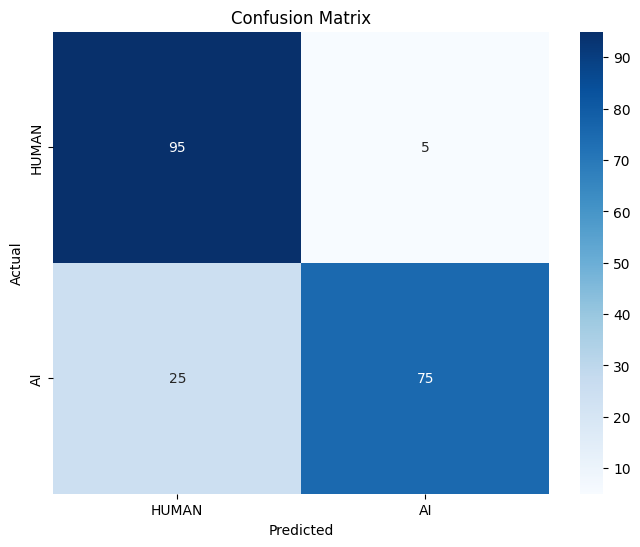

Predictions saved to: test_predictions_indic_bert.csv


In [ ]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_indic_bert.csv"
)

####Save model-1

In [ ]:
trainer.save_model("./my_finetuned_model_indic_bert_85")
tokenizer.save_pretrained("./my_finetuned_model_indic_bert_85")

('./my_finetuned_model_indic_bert_85/tokenizer_config.json',
 './my_finetuned_model_indic_bert_85/special_tokens_map.json',
 './my_finetuned_model_indic_bert_85/spiece.model',
 './my_finetuned_model_indic_bert_85/added_tokens.json',
 './my_finetuned_model_indic_bert_85/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_indic_bert_85.zip /content/my_finetuned_model_indic_bert_85

  adding: content/my_finetuned_model_indic_bert_85/ (stored 0%)
  adding: content/my_finetuned_model_indic_bert_85/model.safetensors (deflated 7%)
  adding: content/my_finetuned_model_indic_bert_85/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_indic_bert_85/spiece.model (deflated 60%)
  adding: content/my_finetuned_model_indic_bert_85/config.json (deflated 53%)
  adding: content/my_finetuned_model_indic_bert_85/tokenizer_config.json (deflated 74%)
  adding: content/my_finetuned_model_indic_bert_85/special_tokens_map.json (deflated 49%)
  adding: content/my_finetuned_model_indic_bert_85/tokenizer.json (deflated 77%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_indic_bert_93.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

####Load old AI indic model

In [ ]:
!unzip /content/my_finetuned_model_indic_bert_1.zip

Archive:  /content/my_finetuned_model_indic_bert_1.zip
   creating: content/my_finetuned_model_indic_bert_1/
  inflating: content/my_finetuned_model_indic_bert_1/special_tokens_map.json  
  inflating: content/my_finetuned_model_indic_bert_1/tokenizer_config.json  
  inflating: content/my_finetuned_model_indic_bert_1/config.json  
  inflating: content/my_finetuned_model_indic_bert_1/spiece.model  
  inflating: content/my_finetuned_model_indic_bert_1/model.safetensors  
  inflating: content/my_finetuned_model_indic_bert_1/tokenizer.json  
  inflating: content/my_finetuned_model_indic_bert_1/training_args.bin  


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("/content/my_finetuned_model_indic_bert_1")
tokenizer = AutoTokenizer.from_pretrained("/content/my_finetuned_model_indic_bert_1")

trainer = Trainer(
    model=model,
    tokenizer=tokenizer,
)

<ipython-input-35-5038f7fa8d6c>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


###Model___2

####Model-2: XLM

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('xlm-roberta-base')

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [ ]:
train_dataset = MalayalDataset(train_encodings, list(train_labels))
val_dataset = MalayalDataset(val_encodings, list(val_labels))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('xlm-roberta-base', num_labels=2)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-33-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.427612
2,No log,0.341164
3,No log,0.214652


TrainOutput(global_step=120, training_loss=0.4583461125691732, metrics={'train_runtime': 122.9578, 'train_samples_per_second': 15.615, 'train_steps_per_second': 0.976, 'total_flos': 126293306572800.0, 'train_loss': 0.4583461125691732, 'epoch': 3.0})

In [ ]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       1.00      0.84      0.91        80
          AI       0.86      1.00      0.92        80

    accuracy                           0.92       160
   macro avg       0.93      0.92      0.92       160
weighted avg       0.93      0.92      0.92       160



####Test Model-2

Accuracy: 0.8700

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.91      0.82      0.86       100
          AI       0.84      0.92      0.88       100

    accuracy                           0.87       200
   macro avg       0.87      0.87      0.87       200
weighted avg       0.87      0.87      0.87       200



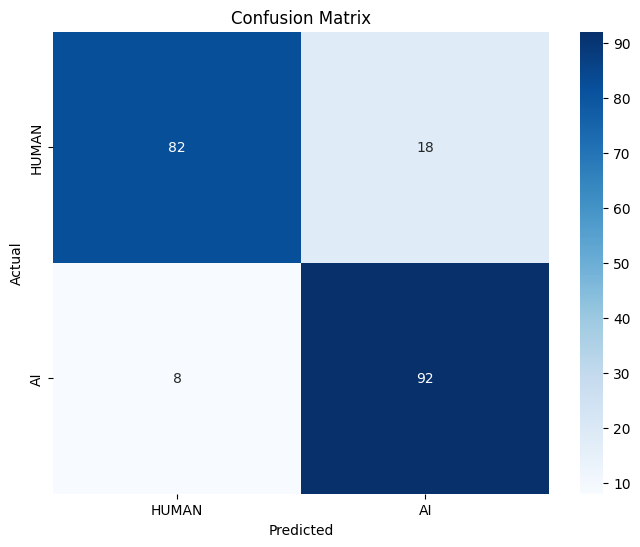

Predictions saved to: test_predictions_xlm.csv


In [ ]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_xlm.csv"
)

####Save model-2

In [ ]:
trainer.save_model("./my_finetuned_model_xlm")
tokenizer.save_pretrained("./my_finetuned_model_xlm")

('./my_finetuned_model_xlb/tokenizer_config.json',
 './my_finetuned_model_xlb/special_tokens_map.json',
 './my_finetuned_model_xlb/sentencepiece.bpe.model',
 './my_finetuned_model_xlb/added_tokens.json',
 './my_finetuned_model_xlb/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_xlm.zip /content/my_finetuned_model_xlm

  adding: content/my_finetuned_model_xlb/ (stored 0%)
  adding: content/my_finetuned_model_xlb/model.safetensors (deflated 22%)
  adding: content/my_finetuned_model_xlb/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_xlb/sentencepiece.bpe.model (deflated 49%)
  adding: content/my_finetuned_model_xlb/config.json (deflated 50%)
  adding: content/my_finetuned_model_xlb/tokenizer_config.json (deflated 76%)
  adding: content/my_finetuned_model_xlb/special_tokens_map.json (deflated 52%)
  adding: content/my_finetuned_model_xlb/tokenizer.json (deflated 76%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_xlm.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Model____3

####Model-3: muril-base-cased

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('google/muril-base-cased')

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

In [ ]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [ ]:
train_dataset = MalayalDataset(train_encodings, list(train_labels))
val_dataset = MalayalDataset(val_encodings, list(val_labels))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('google/muril-base-cased', num_labels=2)

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google/muril-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-40-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.650235
2,No log,0.590323
3,No log,0.564220


TrainOutput(global_step=120, training_loss=0.6319713592529297, metrics={'train_runtime': 126.1388, 'train_samples_per_second': 15.221, 'train_steps_per_second': 0.951, 'total_flos': 118399974912000.0, 'train_loss': 0.6319713592529297, 'epoch': 3.0})

In [ ]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       0.97      0.91      0.94        80
          AI       0.92      0.97      0.95        80

    accuracy                           0.94       160
   macro avg       0.95      0.94      0.94       160
weighted avg       0.95      0.94      0.94       160



####Test Model-3

Accuracy: 0.9000

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.87      0.94      0.90       100
          AI       0.93      0.86      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



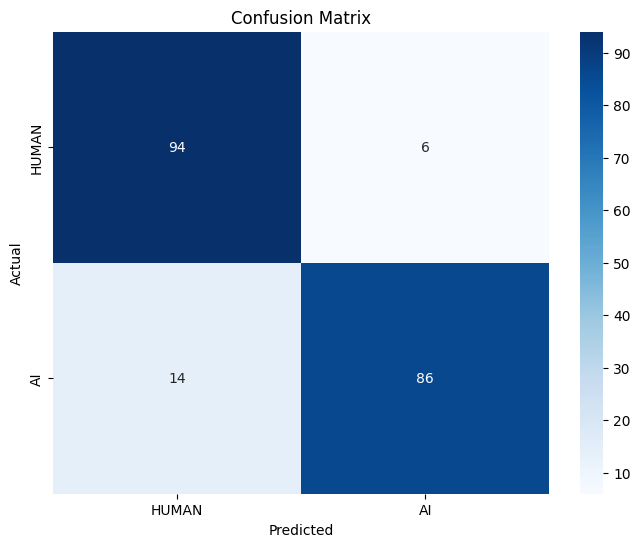

Predictions saved to: test_predictions_MuRIL.csv


In [ ]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_MuRIL.csv"
)

####Save Model-3

In [ ]:
trainer.save_model("./my_finetuned_model_muril")
tokenizer.save_pretrained("./my_finetuned_model_muril")

('./my_finetuned_model_muril/tokenizer_config.json',
 './my_finetuned_model_muril/special_tokens_map.json',
 './my_finetuned_model_muril/vocab.txt',
 './my_finetuned_model_muril/added_tokens.json',
 './my_finetuned_model_muril/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_xlm.zip /content/my_finetuned_model_muril

  adding: content/my_finetuned_model_muril/ (stored 0%)
  adding: content/my_finetuned_model_muril/model.safetensors (deflated 7%)
  adding: content/my_finetuned_model_muril/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_muril/config.json (deflated 50%)
  adding: content/my_finetuned_model_muril/tokenizer_config.json (deflated 75%)
  adding: content/my_finetuned_model_muril/special_tokens_map.json (deflated 42%)
  adding: content/my_finetuned_model_muril/vocab.txt (deflated 61%)
  adding: content/my_finetuned_model_muril/tokenizer.json (deflated 70%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_xlm.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Model____4

####Model-4:Malayalam Bert

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('l3cube-pune/malayalam-bert')

tokenizer_config.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [ ]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [ ]:
train_dataset = MalayalDataset(train_encodings, list(train_labels))
val_dataset = MalayalDataset(val_encodings, list(val_labels))

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained('l3cube-pune/malayalam-bert', num_labels=2)

config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at l3cube-pune/malayalam-bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-47-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,No log,0.618302
2,No log,0.536797
3,No log,0.508522


TrainOutput(global_step=120, training_loss=0.5990973790486653, metrics={'train_runtime': 90.6122, 'train_samples_per_second': 21.189, 'train_steps_per_second': 1.324, 'total_flos': 118399974912000.0, 'train_loss': 0.5990973790486653, 'epoch': 3.0})

In [ ]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       0.99      0.95      0.97        80
          AI       0.95      0.99      0.97        80

    accuracy                           0.97       160
   macro avg       0.97      0.97      0.97       160
weighted avg       0.97      0.97      0.97       160



####Test Model-4

Accuracy: 0.9250

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.91      0.94      0.93       100
          AI       0.94      0.91      0.92       100

    accuracy                           0.93       200
   macro avg       0.93      0.93      0.92       200
weighted avg       0.93      0.93      0.92       200



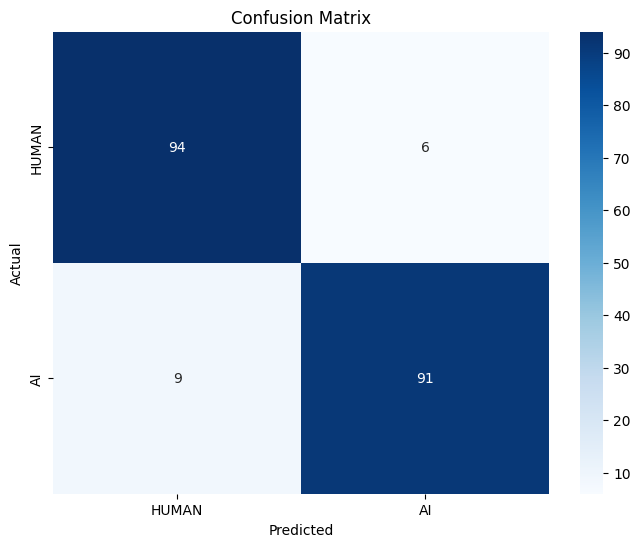

Predictions saved to: test_predictions_mal_bert.csv


In [ ]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_mal_bert.csv"
)

####Save model-4

In [ ]:
trainer.save_model("./my_finetuned_model_mal_bert")
tokenizer.save_pretrained("./my_finetuned_model_mal_bert")

('./my_finetuned_model_xlb/tokenizer_config.json',
 './my_finetuned_model_xlb/special_tokens_map.json',
 './my_finetuned_model_xlb/sentencepiece.bpe.model',
 './my_finetuned_model_xlb/added_tokens.json',
 './my_finetuned_model_xlb/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_mal_bert.zip /content/my_finetuned_model_mal_bert

  adding: content/my_finetuned_model_xlb/ (stored 0%)
  adding: content/my_finetuned_model_xlb/model.safetensors (deflated 22%)
  adding: content/my_finetuned_model_xlb/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_xlb/sentencepiece.bpe.model (deflated 49%)
  adding: content/my_finetuned_model_xlb/config.json (deflated 50%)
  adding: content/my_finetuned_model_xlb/tokenizer_config.json (deflated 76%)
  adding: content/my_finetuned_model_xlb/special_tokens_map.json (deflated 52%)
  adding: content/my_finetuned_model_xlb/tokenizer.json (deflated 76%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_mal_bert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

###Model____5

####Model-5:Indic-SBERT

In [20]:
tokenizer = AutoTokenizer.from_pretrained('l3cube-pune/indic-sentence-bert-nli')

tokenizer_config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/6.41M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

In [21]:
processed_data = tokenize_and_split(
    train_data,
    tokenizer=tokenizer,
    test_size=0.2,
    max_length=128,
    random_state=42
)

train_encodings = processed_data["train_encodings"]
val_encodings = processed_data["val_encodings"]
train_labels = processed_data["train_labels"]
val_labels = processed_data["val_labels"]

In [22]:
train_dataset = MalayalDataset(train_encodings, list(train_labels))
val_dataset = MalayalDataset(val_encodings, list(val_labels))

In [23]:
model = AutoModelForSequenceClassification.from_pretrained('l3cube-pune/malayalam-bert', num_labels=2)

config.json:   0%|          | 0.00/664 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/951M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at l3cube-pune/malayalam-bert and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
training_args = TrainingArguments(
    output_dir='./results',
    evaluation_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir='./logs',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-24-d1cec90c521d>:12: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.


<IPython.core.display.Javascript object>

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch,Training Loss,Validation Loss
1,No log,0.617495
2,No log,0.531047
3,No log,0.508854


TrainOutput(global_step=120, training_loss=0.5904940287272136, metrics={'train_runtime': 92.8579, 'train_samples_per_second': 20.677, 'train_steps_per_second': 1.292, 'total_flos': 118399974912000.0, 'train_loss': 0.5904940287272136, 'epoch': 3.0})

In [25]:
val_preds = trainer.predict(val_dataset)
val_pred_labels = np.argmax(val_preds.predictions, axis=1)
print(classification_report(val_labels, val_pred_labels, target_names=["HUMAN", "AI"]))

              precision    recall  f1-score   support

       HUMAN       0.95      0.95      0.95        80
          AI       0.95      0.95      0.95        80

    accuracy                           0.95       160
   macro avg       0.95      0.95      0.95       160
weighted avg       0.95      0.95      0.95       160



####Test Model-4

Accuracy: 0.9150

Classification Report:

              precision    recall  f1-score   support

       HUMAN       0.90      0.93      0.92       100
          AI       0.93      0.90      0.91       100

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200



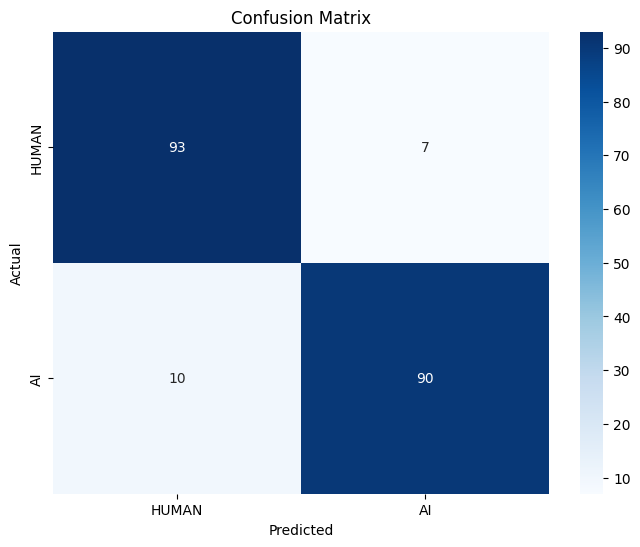

Predictions saved to: test_predictions_mal_bert.csv


In [26]:
test_model(
    model=model,
    tokenizer=tokenizer,
    test_data=test_data,
    label_mapping=label_mapping,
    device=torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    output_file="test_predictions_mal_indic_sbert.csv"
)

####Save model-4

In [ ]:
trainer.save_model("./my_finetuned_model_mal_indic_sbert")
tokenizer.save_pretrained("./my_finetuned_model_indic_sbert")

('./my_finetuned_model_xlb/tokenizer_config.json',
 './my_finetuned_model_xlb/special_tokens_map.json',
 './my_finetuned_model_xlb/sentencepiece.bpe.model',
 './my_finetuned_model_xlb/added_tokens.json',
 './my_finetuned_model_xlb/tokenizer.json')

In [ ]:
!zip -r /content/my_finetuned_model_mal_bert.zip /content/my_finetuned_model_indic_sbert

  adding: content/my_finetuned_model_xlb/ (stored 0%)
  adding: content/my_finetuned_model_xlb/model.safetensors (deflated 22%)
  adding: content/my_finetuned_model_xlb/training_args.bin (deflated 52%)
  adding: content/my_finetuned_model_xlb/sentencepiece.bpe.model (deflated 49%)
  adding: content/my_finetuned_model_xlb/config.json (deflated 50%)
  adding: content/my_finetuned_model_xlb/tokenizer_config.json (deflated 76%)
  adding: content/my_finetuned_model_xlb/special_tokens_map.json (deflated 52%)
  adding: content/my_finetuned_model_xlb/tokenizer.json (deflated 76%)


In [ ]:
from google.colab import files
files.download("/content/my_finetuned_model_mal_indic_sbert.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>